# Chapter 12 - Least Squares Applications 🚀
## Curve Fitting, Multiple Regression, Denoising


## 📘 Overview

Least squares is one of the most practical optimization ideas in data science.

It is used whenever we want a model that best fits noisy observations.

Applications in this chapter:

📈 Polynomial curve fitting  
📊 Multiple regression  
🔊 Signal denoising  
📉 Trend estimation  
🤖 Predictive modeling


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)



## 1️⃣ Polynomial Regression

When relationships are curved, straight lines may fail.
Least squares can fit polynomial models.


In [2]:
x = np.linspace(-3,3,80)
y = 0.8*x**2 + 2*x + 3 + np.random.randn(len(x))*1.8

X = np.column_stack((np.ones(len(x)), x, x**2))
beta = np.linalg.lstsq(X,y,rcond=None)[0]
yhat = X @ beta


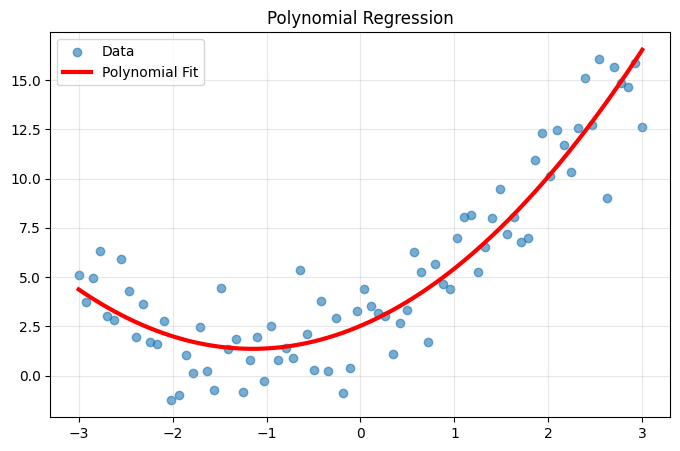

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(x,y,alpha=0.6,label='Data')
plt.plot(x,yhat,color='red',linewidth=3,label='Polynomial Fit')
plt.title("Polynomial Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## Why Important?

Many real systems are nonlinear but can be approximated using linear models on transformed features.



## 2️⃣ Multiple Regression

Use multiple features to predict one target.


In [4]:
n = 120
x1 = np.random.randn(n)
x2 = np.random.randn(n)

y2 = 4 + 2*x1 - 1.5*x2 + np.random.randn(n)

X2 = np.column_stack((np.ones(n),x1,x2))
b2 = np.linalg.lstsq(X2,y2,rcond=None)[0]
print("Estimated coefficients:", b2)


Estimated coefficients: [ 4.05599527  1.90496928 -1.43563901]


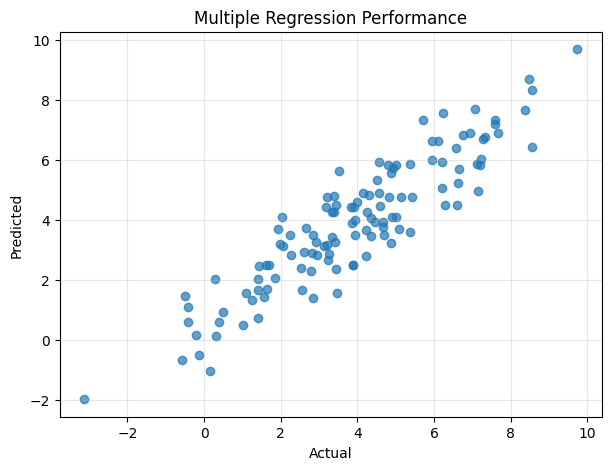

In [5]:
plt.figure(figsize=(7,5))
plt.scatter(y2, X2@b2, alpha=0.7)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Multiple Regression Performance")
plt.grid(alpha=0.3)
plt.show()



## Why Important?

Most machine learning models use multiple input features.



## 3️⃣ Signal Denoising

Least squares ideas help recover clean signals from noisy observations.


In [6]:
t = np.linspace(0,6*np.pi,250)
clean = np.sin(t)
noise = clean + np.random.randn(len(t))*0.35

basis = np.column_stack((np.ones(len(t)), np.sin(t), np.cos(t)))
coef = np.linalg.lstsq(basis, noise, rcond=None)[0]
recon = basis @ coef


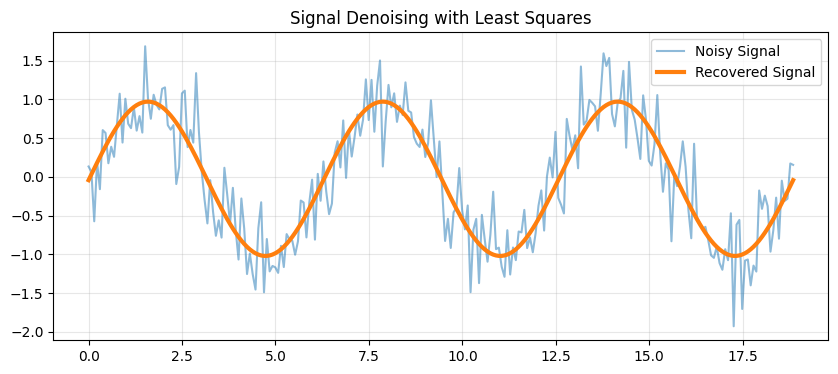

In [7]:
plt.figure(figsize=(10,4))
plt.plot(t,noise,label='Noisy Signal',alpha=0.5)
plt.plot(t,recon,label='Recovered Signal',linewidth=3)
plt.title("Signal Denoising with Least Squares")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 4️⃣ Underfitting vs Better Fit


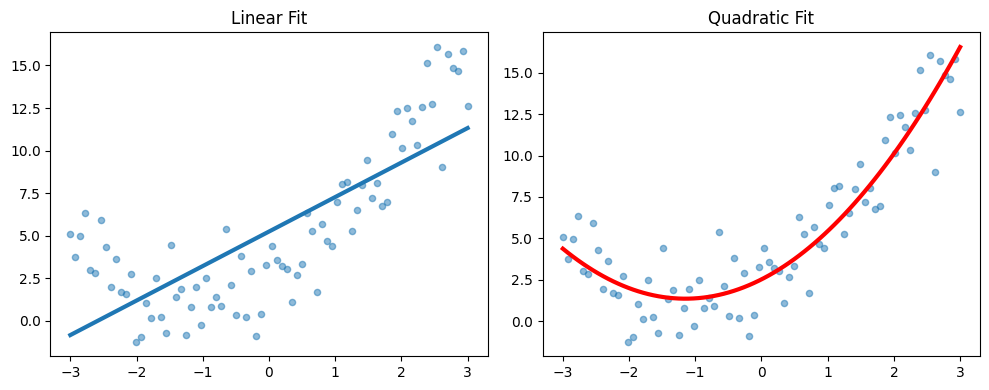

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
coef1 = np.polyfit(x,y,1)
plt.scatter(x,y,s=20,alpha=0.5)
plt.plot(x,np.polyval(coef1,x),linewidth=3)
plt.title("Linear Fit")

plt.subplot(1,2,2)
plt.scatter(x,y,s=20,alpha=0.5)
plt.plot(x,yhat,color='red',linewidth=3)
plt.title("Quadratic Fit")

plt.tight_layout()
plt.show()



## Insight

Model complexity should match the pattern in data.
Too simple = underfitting.
Too complex = overfitting.



## 5️⃣ Residual Distribution


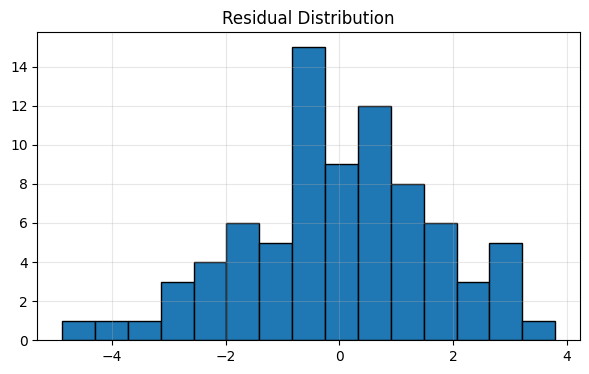

In [9]:
res = y - yhat

plt.figure(figsize=(7,4))
plt.hist(res,bins=15,edgecolor='black')
plt.title("Residual Distribution")
plt.grid(alpha=0.3)
plt.show()



## Why Residuals Matter?

Residuals reveal model quality, bias, and noise structure.



## 6️⃣ Common Beginner Mistakes

❌ Assuming linear means only straight line  
❌ Using too many polynomial terms  
❌ Ignoring residual patterns  
❌ Forgetting train/test evaluation



# 🌟 Chapter Summary

You learned:

✅ Polynomial regression  
✅ Multiple regression  
✅ Signal denoising  
✅ Better fit vs underfit  
✅ Residual diagnostics

Least squares is a foundational tool across statistics and machine learning.
